In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.model_selection import train_test_split
import seaborn as sns
from scipy.stats import pointbiserialr
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold
from scipy.stats import ttest_rel

In [5]:
data = pd.read_csv('data.csv')
data = data.drop(columns=['ap_lo', 'pulse_pressure'])
data.head()


,gender,height,weight,ap_hi,cholesterol,gluc,smoke,alco,active,cardio,age_years,bp_category_encoded
0,1,0.463125,-0.873002,-1.043394,1,1,0,0,1,0,-0.412905,2
1,0,-1.107092,0.933963,0.965018,3,1,0,0,1,1,0.325344,3
2,0,0.070571,-0.715875,0.295547,3,1,0,0,0,1,-0.265255,2
3,1,0.593977,0.698272,1.634488,1,1,0,0,1,1,-0.708204,3
4,0,-1.107092,-1.344384,-1.712865,1,1,0,0,0,0,-0.855854,0


Data splitting

In [6]:
X = data.drop(columns=['cardio'])  # Drop the target column
y = data['cardio']  # Keep only the target column

# 60/20/20 train/val/test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify = y, random_state=4240)  # 60% train, 40% temp
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify = y_temp, random_state=4240)  # 20% val, 20% test

print("Train Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)
print("Test Shape:", X_test.shape)

Train Shape: (39411, 11)
Validation Shape: (13137, 11)
Test Shape: (13138, 11)


Correlation of numerical features with target

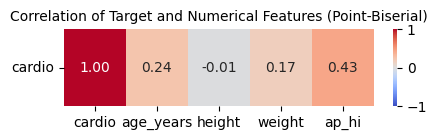

In [7]:
# List of numerical features, including 'cardio'
numerical_features = ['cardio', 'age_years', 'height', 'weight', 'ap_hi']

# Compute the correlation matrix using the default (Pearson) method
correlation_matrix = data[numerical_features].corr()

# Overwrite the correlations for 'cardio' vs each other numerical variable with point-biserial coefficients
for feature in numerical_features:
    if feature != 'cardio':
        pb_corr = pointbiserialr(data['cardio'], data[feature])[0]
        correlation_matrix.loc['cardio', feature] = pb_corr
        correlation_matrix.loc[feature, 'cardio'] = pb_corr

cardio_corr = correlation_matrix.loc[['cardio']]

# Plot the updated correlation matrix
plt.figure(figsize=(5, 1))
ax = sns.heatmap(cardio_corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation of Target and Numerical Features (Point-Biserial)", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.show()

                           IV
bp_category_encoded  0.601504
cholesterol          0.207389
gluc                 0.031706
active               0.005774
smoke                0.001418
alco                 0.000495
gender               0.000099


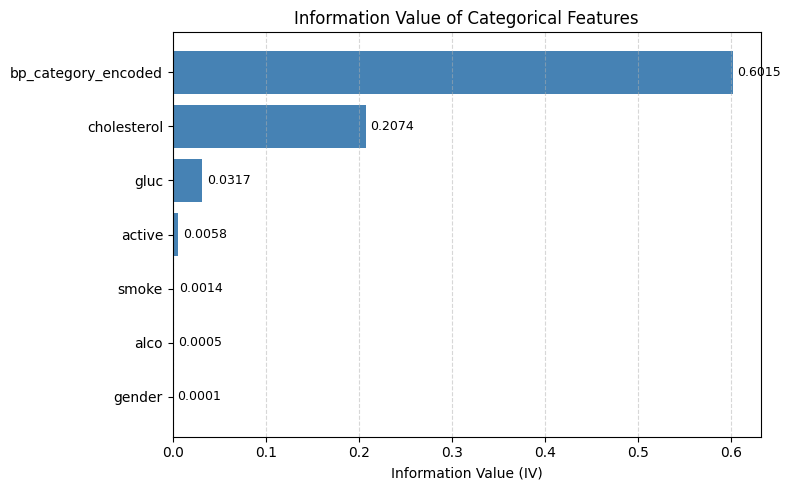

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def calculate_iv(df, feature, target):
    eps = 1e-6  # Avoid division by zero
    grouped = df.groupby(feature)[target]
    
    count_0 = grouped.apply(lambda x: (x == 0).sum())
    count_1 = grouped.apply(lambda x: (x == 1).sum())
    
    total_0 = (df[target] == 0).sum()
    total_1 = (df[target] == 1).sum()

    dist_0 = count_0 / total_0 + eps
    dist_1 = count_1 / total_1 + eps

    woe = np.log(dist_0 / dist_1)
    iv = ((dist_0 - dist_1) * woe).sum()
    
    return iv

# List of categorical features
categorical_features = ['cholesterol', 'gluc', 'gender', 'smoke', 'alco', 'active', 'bp_category_encoded']

# Calculate IVs
iv_dict = {feature: calculate_iv(data, feature, 'cardio') for feature in categorical_features}

# Convert to DataFrame for plotting
iv_df = pd.DataFrame.from_dict(iv_dict, orient='index', columns=['IV']).sort_values(by='IV', ascending=False)

# Print IVs
print(iv_df)

# Plot
plt.figure(figsize=(8, 5))
bars = plt.barh(iv_df.index, iv_df['IV'], color='steelblue')
plt.xlabel('Information Value (IV)')
plt.title('Information Value of Categorical Features')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height() / 2,
             f"{width:.4f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()


# Manual Selection
Numerical drop height  
Categorical drop gender smoke alco

In [5]:
# Drop manually selected features from the dataset
data_manual_model = data.drop(columns=['height', 'gender', 'smoke', 'alco'])

manual_model = LogisticRegression(solver='saga')
manual_model.fit(X_train, y_train)

val_probs = manual_model.predict_proba(X_val)[:, 1]

# === threshold tuning ===

# Grid search for best threshold based on F1-score
thresholds = np.arange(0.30, 0.61, 0.01)
best_threshold = 0
best_f1_ = 0

print("\n--- Threshold Tuning on Validation Set ( F1) ---")
for threshold in thresholds:
    val_preds = (val_probs >= threshold).astype(int)
    f1_ = f1_score(y_val, val_preds)
    # print(f"Threshold: {threshold:.3f} |  F1: {f1_:.4f}")
    
    if f1_ > best_f1_:
        best_f1_ = f1_
        best_threshold = threshold

print(f"\nSelected Threshold: {best_threshold:.3f} ( F1 = {best_f1_:.4f})")

# === Evaluate using best threshold ===

# Training set
train_probs = manual_model.predict_proba(X_train)[:, 1]
manual_y_train_pred = (train_probs >= best_threshold).astype(int)
print(f"\nTraining Classification Report (threshold = {best_threshold}):")
print(classification_report(y_train, manual_y_train_pred, digits=4))

# Validation set
val_preds = (val_probs >= best_threshold).astype(int)
print(f"\nValidation Classification Report (threshold = {best_threshold}):")
print(classification_report(y_val, val_preds, digits=4))

# Test set
test_probs = manual_model.predict_proba(X_test)[:, 1]
manual_y_test_pred = (test_probs >= best_threshold).astype(int)
print(f"\nTest Classification Report (threshold = {best_threshold}):")
print(classification_report(y_test, manual_y_test_pred, digits=4))

# === ANOVA Table for Manual Selection ===

# Subset X_test based on selected features
X_test_manual = X_test.drop(columns=['height', 'gender', 'smoke', 'alco']).reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

# Add intercept
X_test_manual_df = sm.add_constant(X_test_manual)

# Fit logistic regression model with statsmodels
logit_model_test = sm.Logit(y_test_reset, X_test_manual_df)
result_test = logit_model_test.fit()

print("\n=== Test Set ANOVA Table (Manual Selection) ===")
print(result_test.summary())



--- Threshold Tuning on Validation Set ( F1) ---

Selected Threshold: 0.390 ( F1 = 0.7244)

Training Classification Report (threshold = 0.39000000000000007):
              precision    recall  f1-score   support

           0     0.7653    0.6248    0.6879     20314
           1     0.6661    0.7961    0.7253     19097

    accuracy                         0.7078     39411
   macro avg     0.7157    0.7105    0.7066     39411
weighted avg     0.7172    0.7078    0.7061     39411


Validation Classification Report (threshold = 0.39000000000000007):
              precision    recall  f1-score   support

           0     0.7638    0.6255    0.6878      6772
           1     0.6659    0.7942    0.7244      6365

    accuracy                         0.7072     13137
   macro avg     0.7149    0.7099    0.7061     13137
weighted avg     0.7164    0.7072    0.7055     13137


Test Classification Report (threshold = 0.39000000000000007):
              precision    recall  f1-score   support



# Forward Backward Selection

In [6]:
# Initialize Logistic Regression Model
lr = LogisticRegression(solver='saga')

# Sequential Feature Selector (floating forward-backward selection)
sfspp = SFS(lr, 
            k_features=7,             
            forward=True,             
            floating=True,            
            scoring='f1',             
            cv=5)                     

# Fit SFS on training data
sfspp.fit(X_train, y_train)

# Get selected feature names
selected_featurespp = list(sfspp.k_feature_names_)
print("Selected Features (Floating SFS):", selected_featurespp)

# Subset data based on selected features
X_train_sel = X_train[selected_featurespp].reset_index(drop=True)
X_val_sel = X_val[selected_featurespp].reset_index(drop=True)
X_test_sel = X_test[selected_featurespp].reset_index(drop=True)
y_train_reset = y_train.reset_index(drop=True)
y_val_reset = y_val.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

# Train logistic regression model on selected features
lr.fit(X_train_sel, y_train_reset)

# === Threshold tuning using validation set and  F1 ===

val_probs = lr.predict_proba(X_val_sel)[:, 1]
thresholds = np.arange(0.30, 0.61, 0.005)
best_threshold = 0
best_f1_ = 0

print("\n--- Threshold Tuning on Validation Set ( F1) ---")
for threshold in thresholds:
    val_preds = (val_probs >= threshold).astype(int)
    f1_ = f1_score(y_val_reset, val_preds)
     ## print(f"Threshold: {threshold:.3f} |  F1: {f1_:.4f}")
    
    if f1_ > best_f1_:
        best_f1_ = f1_
        best_threshold = threshold

print(f"\nSelected Threshold: {best_threshold:.3f} ( F1 = {best_f1_:.4f})")

# === Evaluate model using best threshold ===

# Training Set
train_probs = lr.predict_proba(X_train_sel)[:, 1]
sel_y_train_pred = (train_probs >= best_threshold).astype(int)
print(f"\nTraining Classification Report (threshold = {best_threshold}):")
print(classification_report(y_train_reset, sel_y_train_pred, digits=4))

# Validation Set
val_preds = (val_probs >= best_threshold).astype(int)
print(f"\nValidation Classification Report (threshold = {best_threshold}):")
print(classification_report(y_val_reset, val_preds, digits=4))

# Test Set
test_probs = lr.predict_proba(X_test_sel)[:, 1]
sel_y_test_pred = (test_probs >= best_threshold).astype(int)
print(f"\nTest Classification Report (threshold = {best_threshold}):")
print(classification_report(y_test_reset, sel_y_test_pred, digits=4))

# ===  ANOVA Table for SFS ===
X_test_sel_df = sm.add_constant(X_test_sel)
logit_model_test = sm.Logit(y_test_reset, X_test_sel_df)
result_test = logit_model_test.fit()

print("\n=== Test Set ANOVA Table (Statsmodels) ===")
print(result_test.summary())

Selected Features (Floating SFS): ['gender', 'weight', 'ap_hi', 'cholesterol', 'alco', 'active', 'age_years']

--- Threshold Tuning on Validation Set ( F1) ---

Selected Threshold: 0.375 ( F1 = 0.7238)

Training Classification Report (threshold = 0.37500000000000006):
              precision    recall  f1-score   support

           0     0.7745    0.5922    0.6712     20314
           1     0.6531    0.8166    0.7257     19097

    accuracy                         0.7009     39411
   macro avg     0.7138    0.7044    0.6985     39411
weighted avg     0.7156    0.7009    0.6976     39411


Validation Classification Report (threshold = 0.37500000000000006):
              precision    recall  f1-score   support

           0     0.7713    0.5926    0.6702      6772
           1     0.6523    0.8130    0.7238      6365

    accuracy                         0.6994     13137
   macro avg     0.7118    0.7028    0.6970     13137
weighted avg     0.7136    0.6994    0.6962     13137


Test Cl

# L1/L2 Regularisation 

grid search for  
penalty, inverse regularisation strength, solver

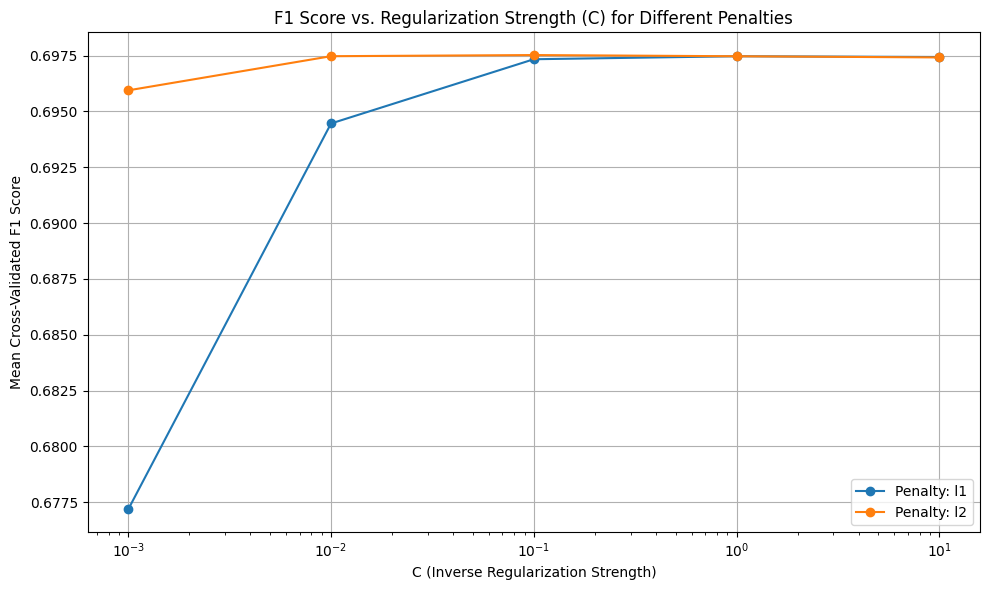

Best parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'saga'}
Best F1 score: 0.6975209588083583


In [7]:
# Define parameter grid
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.001, 0.01, 0.1, 1, 10],
    'solver': ['saga'],  # 'saga' supports both 'l1', ' l2' and No penalty
}

# Initialize logistic regression model
logreg = LogisticRegression(max_iter=1000)

# Grid search with F1 scoring
grid_search = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    scoring='f1',  # or 'f1_macro', 'f1_weighted' as needed
    cv=5,
    return_train_score=True,
    n_jobs=-1
)

# Fit on training data
grid_search.fit(X_train, y_train)

# Results DataFrame
cv_results = pd.DataFrame(grid_search.cv_results_)

# Plot F1 vs. C for each penalty
plt.figure(figsize=(10, 6))
penalties = cv_results['param_penalty'].unique()

for penalty in penalties:
    subset = cv_results[cv_results['param_penalty'] == penalty]
    plt.plot(subset['param_C'], subset['mean_test_score'], marker='o', label=f'Penalty: {penalty}')

plt.xscale('log')
plt.xlabel('C (Inverse Regularization Strength)')
plt.ylabel('Mean Cross-Validated F1 Score')
plt.title('F1 Score vs. Regularization Strength (C) for Different Penalties')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print best config
print("Best parameters:", grid_search.best_params_)
print("Best F1 score:", grid_search.best_score_)


In [8]:
# Set C and threshold
C = 0.1
coef_threshold = 0.01  # Consider only coefficients with abs value > 0.01

# Fit L2-penalized model
model = LogisticRegression(penalty='l2', solver='saga', C=C, max_iter=1000)
model.fit(X_train, y_train)

# Get coefficients and features
coef = model.coef_.flatten()
features = X_train.columns

# Identify "important" features (non-trivially weighted)
selected = features[np.abs(coef) > coef_threshold]

# Display result
print("C =", C)
print("Number of Features with |coef| > 0.01:", len(selected))
print("Selected Features:", ', '.join(selected))


C = 0.1
Number of Features with |coef| > 0.01: 9
Selected Features: height, weight, ap_hi, cholesterol, gluc, smoke, alco, active, age_years


In [9]:
# === Fit the model ===
log_model_ridge = LogisticRegression(penalty='l2', solver='saga', C=0.1, max_iter=1000)
log_model_ridge.fit(X_train, y_train)

val_probs = log_model_ridge.predict_proba(X_val)[:, 1]

# === Threshold tuning using validation set and  F1 ===

thresholds = np.arange(0.30, 0.61, 0.01)
best_threshold = 0.4
best_f1 = 1

for threshold in thresholds:
    val_preds = (val_probs >= threshold).astype(int)
    f1 = f1_score(y_val, val_preds)
    # print(f"Threshold: {threshold:.2f} | Validation F1 Score: {f1:.4f}")
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

# === Evaluate model using best threshold ===

print(f"\n--- Evaluation Using Best Threshold = {best_threshold:.2f} ---")

# Train set evaluation
train_probs = log_model_ridge.predict_proba(X_train)[:, 1]
train_preds = (train_probs >= best_threshold).astype(int)
print("\nTraining Metrics:")
print(classification_report(y_train, train_preds, digits=4))

# Validation set evaluation
val_preds = (val_probs >= best_threshold).astype(int)
print("\nValidation Metrics:")
print(classification_report(y_val, val_preds, digits=4))

# Test set evaluation
test_probs = log_model_ridge.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= best_threshold).astype(int)
print("\nTest Metrics:")
print(classification_report(y_test, test_preds, digits=4))



--- Evaluation Using Best Threshold = 0.40 ---

Training Metrics:
              precision    recall  f1-score   support

           0     0.7606    0.6450    0.6980     20314
           1     0.6749    0.7841    0.7254     19097

    accuracy                         0.7124     39411
   macro avg     0.7178    0.7145    0.7117     39411
weighted avg     0.7191    0.7124    0.7113     39411


Validation Metrics:
              precision    recall  f1-score   support

           0     0.7575    0.6444    0.6964      6772
           1     0.6735    0.7805    0.7231      6365

    accuracy                         0.7104     13137
   macro avg     0.7155    0.7125    0.7097     13137
weighted avg     0.7168    0.7104    0.7093     13137


Test Metrics:
              precision    recall  f1-score   support

           0     0.7596    0.6410    0.6953      6772
           1     0.6725    0.7842    0.7241      6366

    accuracy                         0.7104     13138
   macro avg     0.7160  

In [10]:
# === display coefficients ===
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_model_ridge.coef_.flatten()
})

# Sort by absolute magnitude
coef_df['|Coefficient|'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='|Coefficient|', ascending=False)

# Display
print(coef_df)


                Feature  Coefficient  |Coefficient|
3                 ap_hi     0.961417       0.961417
4           cholesterol     0.510008       0.510008
9             age_years     0.362491       0.362491
8                active    -0.243017       0.243017
7                  alco    -0.200170       0.200170
2                weight     0.161409       0.161409
6                 smoke    -0.157113       0.157113
5                  gluc    -0.127026       0.127026
1                height    -0.052383       0.052383
10  bp_category_encoded     0.007948       0.007948
0                gender    -0.001930       0.001930


# 10-fold Cross Validation

In [11]:
# === set up for manual model ===
data_manual_model = data.drop(columns=['height', 'gender', 'smoke', 'alco'])
X = data_manual_model.drop(columns=['cardio'])
y = data_manual_model['cardio']
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 4240)  # 80% train+val, 20% test

In [12]:
# Define model parameters
threshold = 0.39
C_value = 0.1
n_splits = 10

# Prepare lists to store metrics
f1_scores = []
precision_scores = []
recall_scores = []

# For tracking the best model
best_model = None
best_f1 = -1

# Define StratifiedKFold
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=4240)

# Fold counter
fold = 1

for train_index, val_index in skf.split(X_train_val, y_train_val):
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]
    
    # Fit model
    model = LogisticRegression(solver='saga')
    model.fit(X_train_fold, y_train_fold)

    # Predict probabilities
    y_probs = model.predict_proba(X_val_fold)[:, 1]
    y_pred = (y_probs >= threshold).astype(int)

    # Evaluate and store scores
    f1 = f1_score(y_val_fold, y_pred)
    precision = precision_score(y_val_fold, y_pred)
    recall = recall_score(y_val_fold, y_pred)

    f1_scores.append(f1)
    precision_scores.append(precision)
    recall_scores.append(recall)

    print(f"Fold {fold}: Precision = {precision:.4f}, Recall = {recall:.4f}, F1 Score = {f1:.4f}")

    # Update best model
    if f1 > best_f1:
        best_model = model
        best_f1 = f1

    fold += 1

# Show average results
print("\n--- Average Scores over 10 folds ---")
print(f"Average Precision: {np.mean(precision_scores):.4f}")
print(f"Average Recall:    {np.mean(recall_scores):.4f}")
print(f"Average F1 Score:  {np.mean(f1_scores):.4f}")

Fold 1: Precision = 0.6762, Recall = 0.8070, F1 Score = 0.7358
Fold 2: Precision = 0.6648, Recall = 0.8012, F1 Score = 0.7267
Fold 3: Precision = 0.6699, Recall = 0.8143, F1 Score = 0.7351
Fold 4: Precision = 0.6810, Recall = 0.8062, F1 Score = 0.7384
Fold 5: Precision = 0.6640, Recall = 0.8032, F1 Score = 0.7270
Fold 6: Precision = 0.6577, Recall = 0.7907, F1 Score = 0.7181
Fold 7: Precision = 0.6539, Recall = 0.7925, F1 Score = 0.7166
Fold 8: Precision = 0.6642, Recall = 0.7807, F1 Score = 0.7178
Fold 9: Precision = 0.6640, Recall = 0.7822, F1 Score = 0.7183
Fold 10: Precision = 0.6647, Recall = 0.7968, F1 Score = 0.7248

--- Average Scores over 10 folds ---
Average Precision: 0.6661
Average Recall:    0.7975
Average F1 Score:  0.7258


In [3]:
# === MLP scores ===
mlp_f1_scores = [
    0.7362, 0.7274, 0.7198, 0.7308, 0.7254,
    0.7350, 0.7364, 0.7196, 0.7233, 0.7266
]
mlp_precision_scores = [
    0.7124, 0.7018, 0.6975, 0.6955, 0.7059,
    0.7079, 0.7003, 0.6955, 0.6989, 0.6855
]
mlp_recall_scores = [
    0.7617, 0.7550, 0.7435, 0.7698, 0.7459,
    0.7643, 0.7765, 0.7455, 0.7494, 0.7730
]

# === RF scores ===
RF_f1_scores = [
    0.7303, 0.7266, 0.73386, 0.7258, 0.73503,
    0.7288, 0.7226, 0.7283, 0.7353, 0.7242
]
RF_precision_scores = [
    0.6579, 0.6611, 0.6653, 0.6534, 0.6577,
    0.6598, 0.6527, 0.6583, 0.6620, 0.6548
]
RF_recall_scores = [
    0.8206, 0.8065, 0.8175, 0.8162, 0.8209,
    0.8140, 0.8092, 0.8149, 0.8269, 0.8099
]

# === Paired t-test for each metric ===

metrics = {
    "F1 Score": (mlp_f1_scores, RF_f1_scores),
    "Precision": (mlp_precision_scores, RF_precision_scores),
    "Recall": (mlp_recall_scores, RF_recall_scores)
}

for metric, (mlp_vals, RF_vals) in metrics.items():
    t_stat, p_val = ttest_rel(mlp_vals, RF_vals)
    print(f"\n--- Paired T-Test for {metric} ---")
    print("MLP:     ", np.round(mlp_vals, 4))
    print("RF:  ", np.round(RF_vals, 4))
    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value:     {p_val:.4f}")

    if p_val < 0.05:
        print("Statistically significant difference (p < 0.05)")
    else:
        print("Not statistically significant (p ≥ 0.05)")



--- Paired T-Test for F1 Score ---
MLP:      [0.7362 0.7274 0.7198 0.7308 0.7254 0.735  0.7364 0.7196 0.7233 0.7266]
RF:   [0.7303 0.7266 0.7339 0.7258 0.735  0.7288 0.7226 0.7283 0.7353 0.7242]
T-statistic: -0.3463
P-value:     0.7371
Not statistically significant (p ≥ 0.05)

--- Paired T-Test for Precision ---
MLP:      [0.7124 0.7018 0.6975 0.6955 0.7059 0.7079 0.7003 0.6955 0.6989 0.6855]
RF:   [0.6579 0.6611 0.6653 0.6534 0.6577 0.6598 0.6527 0.6583 0.662  0.6548]
T-statistic: 17.1139
P-value:     0.0000
Statistically significant difference (p < 0.05)

--- Paired T-Test for Recall ---
MLP:      [0.7617 0.755  0.7435 0.7698 0.7459 0.7643 0.7765 0.7455 0.7494 0.773 ]
RF:   [0.8206 0.8065 0.8175 0.8162 0.8209 0.814  0.8092 0.8149 0.8269 0.8099]
T-statistic: -11.1217
P-value:     0.0000
Statistically significant difference (p < 0.05)


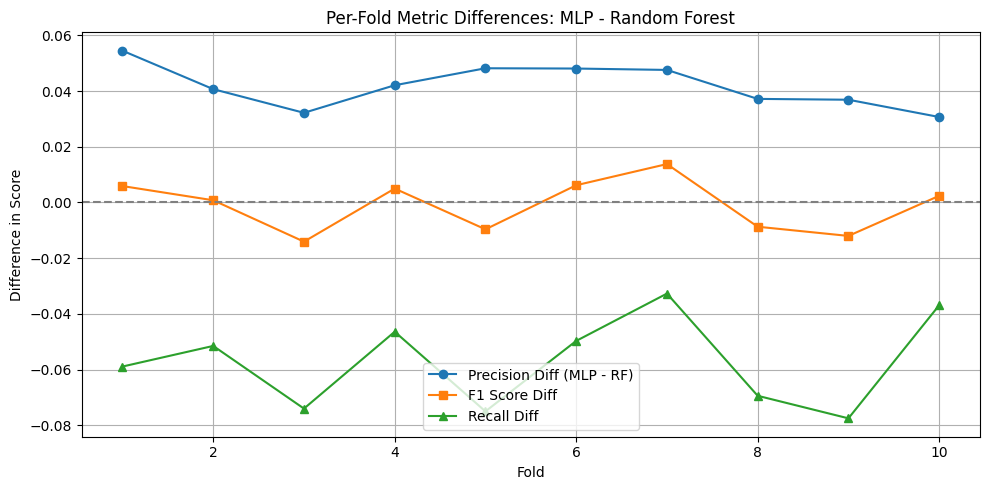

In [6]:
# === Plotting the differences ===
folds = np.arange(1, 11)

plt.figure(figsize=(10, 5))

plt.plot(folds, np.array(mlp_precision_scores) - np.array(RF_precision_scores), marker='o', label='Precision Diff (MLP - RF)')
plt.plot(folds, np.array(mlp_f1_scores) - np.array(RF_f1_scores), marker='s', label='F1 Score Diff')
plt.plot(folds, np.array(mlp_recall_scores) - np.array(RF_recall_scores), marker='^', label='Recall Diff')

plt.axhline(0, color='gray', linestyle='--')
plt.title('Per-Fold Metric Differences: MLP - Random Forest')
plt.xlabel('Fold')
plt.ylabel('Difference in Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
